In [411]:
import numpy as np
import pandas as pd

In [412]:
df = pd.read_csv('gurgaon_properties_final.csv')

In [413]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3957 entries, 0 to 3956
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   property_type    3957 non-null   object 
 1   society          3957 non-null   object 
 2   sector           3957 non-null   object 
 3   price            3937 non-null   float64
 4   price_per_sqft   3937 non-null   float64
 5   Estimated_area   3937 non-null   float64
 6   areaWithType     3957 non-null   object 
 7   bedRoom          3957 non-null   int64  
 8   bathroom         3957 non-null   int64  
 9   balcony          3957 non-null   object 
 10  additionalRoom   3957 non-null   object 
 11  floorNum         3938 non-null   float64
 12  facing           3957 non-null   object 
 13  agePossession    3956 non-null   object 
 14  nearbyLocations  3752 non-null   object 
 15  description      3957 non-null   object 
 16  furnishDetails   2925 non-null   object 
 17  features      

In [414]:
df.duplicated().sum()   

np.int64(123)

In [415]:
df.head(2)

,property_type,society,sector,price,price_per_sqft,Estimated_area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,description,furnishDetails,features
0,flat,ss,sector 85,1.18,7170.0,1646.0,Super Built up area 1640(152.36 sq.m.)Built Up...,2,2,3,not available,4.0,West,1 to 5 Year Old,"['Sri Radhe Krishna Temple', 'Ekta Hospital', ...",This lovely 2 bhk apartment/flat in sector 85 ...,"['4 AC', 'No Bed', 'No Chimney', 'No Curtains'...","['Feng Shui / Vaastu Compliant', 'Security / F..."
1,house,independent,sector 57,8.31,24171.0,3438.0,Plot area 382(319.4 sq.m.),5,6,3+,"store room,pooja room,servant room,study room",4.0,North-East,10+ Year Old,"['Radhakrishna Shani Mandir', 'Sanatan Dharm M...","Sushant lok-3\nBlock-B, corner villa at plot r...",[],"['Feng Shui / Vaastu Compliant', 'False Ceilin..."


## 1. areaWithType

In [416]:
df.sample(5)[['price','Estimated_area','areaWithType']]

,price,Estimated_area,areaWithType
1872,0.79,996.0,Super Built up area 1457(135.36 sq.m.)Carpet a...
194,1.50,1920.0,Super Built up area 1920(178.37 sq.m.)
1761,3.50,2937.0,Built Up area: 2937 (272.86 sq.m.)Carpet area:...
2608,1.25,2575.0,Super Built up area 2575(239.23 sq.m.)
3050,3.50,1440.0,Carpet area: 160 (133.78 sq.m.)


In [417]:
import re
def convert_unit_to_sqft(value, unit):
    if value is None:
        return None

    if unit == 'sq.m':
        return round(value * 10.7639, 2)
    elif unit == 'sq.yards':
        return round(value * 9, 2)
    else:  # sq.ft or implicit
        return float(value)



In [418]:
def extract_super_built_up(text):
    if not isinstance(text, str):
        return None

    match = re.search(
        r'Super Built up area\s*(\d+\.?\d*)',
        text,
        re.IGNORECASE
    )
    return float(match.group(1)) if match else None


In [419]:
def extract_built_up(text):
    if not isinstance(text, str):
        return None

    match = re.search(
        r'(?<!Super )Built Up area\s*[:\-]?\s*(\d+\.?\d*)\s*(sq\.yards|sq\.m|sq\.ft)?',
        text,
        re.IGNORECASE
    )

    if match:
        value = float(match.group(1))
        unit = match.group(2)
        return convert_unit_to_sqft(value, unit)

    return None



In [420]:
def extract_carpet(text):
    if not isinstance(text, str):
        return None

    match = re.search(
        r'Carpet area\s*[:\-]?\s*(\d+\.?\d*)\s*(sq\.yards|sq\.m|sq\.ft)?',
        text,
        re.IGNORECASE
    )

    if match:
        value = float(match.group(1))
        unit = match.group(2)
        return convert_unit_to_sqft(value, unit)

    return None


In [421]:
df['super_built_up_area'] = df['areaWithType'].apply(extract_super_built_up)
df['built_up_area']       = df['areaWithType'].apply(extract_built_up)
df['carpet_area']         = df['areaWithType'].apply(extract_carpet)


In [422]:
df[['price','property_type','Estimated_area','areaWithType','super_built_up_area','built_up_area','carpet_area']].sample(10)

,price,property_type,Estimated_area,areaWithType,super_built_up_area,built_up_area,carpet_area
1867,2.75,house,2228.0,Built Up area: 2228 (206.99 sq.m.),NaN,2228.0,NaN
3353,1.30,flat,1997.0,Built Up area: 1997 (185.53 sq.m.),NaN,1997.0,NaN
1373,1.78,flat,2191.0,Super Built up area 2191(203.55 sq.m.),2191.0,NaN,NaN
1752,8.48,house,3600.0,Plot area 400(334.45 sq.m.),NaN,NaN,NaN
2081,3.60,house,1728.0,Plot area 192(160.54 sq.m.),NaN,NaN,NaN
1125,1.20,flat,1760.0,Super Built up area 1760(163.51 sq.m.)Built Up...,1760.0,1186.0,1130.0
431,0.68,house,1755.0,Built Up area: 1755 (163.04 sq.m.),NaN,1755.0,NaN
2357,3.99,flat,3090.0,Super Built up area 3090(287.07 sq.m.),3090.0,NaN,NaN
1078,6.50,flat,3142.0,Super Built up area 2997(278.43 sq.m.),2997.0,NaN,NaN
2763,1.24,flat,1755.0,Super Built up area 1755(163.04 sq.m.)Built Up...,1755.0,1600.0,1400.0


In [423]:
#  index 263 
df.iloc[262]


property_type                                                      house
society                                                      independent
sector                                                        sector 110
price                                                                1.0
price_per_sqft                                                    8796.0
Estimated_area                                                    1137.0
areaWithType           Plot area 120(100.34 sq.m.)Built Up area: 120 ...
bedRoom                                                                3
bathroom                                                               2
balcony                                                                2
additionalRoom                                                pooja room
floorNum                                                             1.0
facing                                                             North
agePossession                                      

In [424]:
df.duplicated().sum()

np.int64(123)

In [425]:
df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))][['price','property_type','Estimated_area','areaWithType','super_built_up_area','built_up_area','carpet_area']].shape

(537, 7)

In [426]:
df[df['areaWithType'].str.contains('Plot')][['price','property_type','Estimated_area','areaWithType','super_built_up_area','built_up_area','carpet_area']].head(5)

,price,property_type,Estimated_area,areaWithType,super_built_up_area,built_up_area,carpet_area
1,8.31,house,3438.0,Plot area 382(319.4 sq.m.),NaN,NaN,NaN
2,1.25,house,1080.0,Plot area 120(100.34 sq.m.)Built Up area: 120 ...,NaN,1080.0,NaN
12,0.95,house,1065.0,Plot area 1065(98.94 sq.m.),NaN,NaN,NaN
19,6.50,house,1800.0,Plot area 200(167.23 sq.m.),NaN,NaN,NaN
24,0.65,house,585.0,Plot area 65(54.35 sq.m.),NaN,NaN,NaN


In [427]:
df.isnull().sum()

property_type             0
society                   0
sector                    0
price                    20
price_per_sqft           20
Estimated_area           20
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
additionalRoom            0
floorNum                 19
facing                    0
agePossession             1
nearbyLocations         205
description               0
furnishDetails         1032
features                706
super_built_up_area    2023
built_up_area          2726
carpet_area            1954
dtype: int64

In [428]:
all_nan_df = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price','property_type','Estimated_area','areaWithType','super_built_up_area','built_up_area','carpet_area']]


In [429]:
all_nan_df.head()

,price,property_type,Estimated_area,areaWithType,super_built_up_area,built_up_area,carpet_area
1,8.31,house,3438.0,Plot area 382(319.4 sq.m.),NaN,NaN,NaN
12,0.95,house,1065.0,Plot area 1065(98.94 sq.m.),NaN,NaN,NaN
19,6.50,house,1800.0,Plot area 200(167.23 sq.m.),NaN,NaN,NaN
24,0.65,house,585.0,Plot area 65(54.35 sq.m.),NaN,NaN,NaN
30,10.50,house,3240.0,Plot area 360(301.01 sq.m.),NaN,NaN,NaN


In [430]:
all_nan_index = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price','property_type','Estimated_area','areaWithType','super_built_up_area','built_up_area','carpet_area']].index

In [431]:
import re
import re

def extract_plot_area_sqft(text):
    if not isinstance(text, str):
        return None

    # Case: Plot area 65(54.35 sq.m.)
    match = re.search(
        r'Plot area\s*(\d+\.?\d*)\s*\(\s*(\d+\.?\d*)\s*sq\.m',
        text,
        re.IGNORECASE
    )

    if match:
        plot_value = float(match.group(1))   # e.g. 65
        sqm_value  = float(match.group(2))   # e.g. 54.35

        # Validate sq.yard logic (optional but safe)
        ratio = plot_value / sqm_value
        if 1.15 <= ratio <= 1.25:
            return round(plot_value * 9, 2)  # sq.yards → sqft
        if 10 <= ratio <= 11.5:
            return round(plot_value, 2)

    # Fallback: explicit units (rare for plots)
    match2 = re.search(
        r'Plot area\s*(\d+\.?\d*)\s*(sq\.yards|sq\.m|sq\.ft)',
        text,
        re.IGNORECASE
    )

    if match2:
        value = float(match2.group(1))
        unit  = match2.group(2)

        if unit == 'sq.m':
            return round(value * 10.7639, 2)
        elif unit == 'sq.yards':
            return round(value * 9, 2)
        else:
            return value

    return None



In [432]:
all_nan_df['built_up_area'] = all_nan_df['areaWithType'].apply(extract_plot_area_sqft)

# Update the original dataframe
#gurgaon_properties.update(filtered_rows)

In [433]:
all_nan_df

,price,property_type,Estimated_area,areaWithType,super_built_up_area,built_up_area,carpet_area
1,8.31,house,3438.0,Plot area 382(319.4 sq.m.),NaN,3438.0,NaN
12,0.95,house,1065.0,Plot area 1065(98.94 sq.m.),NaN,1065.0,NaN
19,6.50,house,1800.0,Plot area 200(167.23 sq.m.),NaN,1800.0,NaN
24,0.65,house,585.0,Plot area 65(54.35 sq.m.),NaN,585.0,NaN
30,10.50,house,3240.0,Plot area 360(301.01 sq.m.),NaN,3240.0,NaN
...,...,...,...,...,...,...,...
3942,4.35,house,1350.0,Plot area 150(125.42 sq.m.),NaN,1350.0,NaN
3945,0.65,house,1125.0,Plot area 1125(104.52 sq.m.),NaN,1125.0,NaN
3949,5.80,house,4518.0,Plot area 502(419.74 sq.m.),NaN,4518.0,NaN
3950,3.71,house,1872.0,Plot area 208(173.91 sq.m.),NaN,1872.0,NaN


In [434]:
# update the original dataframe
df.update(all_nan_df)

In [435]:
df.isnull().sum()

property_type             0
society                   0
sector                    0
price                    20
price_per_sqft           20
Estimated_area           20
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
additionalRoom            0
floorNum                 19
facing                    0
agePossession             1
nearbyLocations         205
description               0
furnishDetails         1032
features                706
super_built_up_area    2023
built_up_area          2122
carpet_area            1954
dtype: int64

## 2.additionalRoom

In [436]:
df['additionalRoom'].value_counts()

additionalRoom
not available                                    1688
servant room                                      710
study room                                        251
others                                            236
pooja room                                        170
                                                 ... 
servant room,store room,study room,pooja room       1
servant room,study room,store room,pooja room       1
study room,store room,pooja room                    1
store room,study room                               1
others,study room                                   1
Name: count, Length: 66, dtype: int64

In [437]:
# additional room
# List of new columns to be created
new_cols = ['study room', 'servant room', 'store room', 'pooja room', 'others']

# Populate the new columns based on the "additionalRoom" column
for col in new_cols:
    df[col] = df['additionalRoom'].str.contains(col).astype(int)

In [438]:
df.sample(5)[['additionalRoom','study room', 'servant room', 'store room', 'pooja room', 'others']]

,additionalRoom,study room,servant room,store room,pooja room,others
3445,not available,0,0,0,0,0
1439,study room,1,0,0,0,0
1904,not available,0,0,0,0,0
2535,"study room,pooja room",1,0,0,1,0
585,others,0,0,0,0,1


In [439]:
df.head()

,property_type,society,sector,price,price_per_sqft,Estimated_area,areaWithType,bedRoom,bathroom,balcony,...,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others
0,flat,ss,sector 85,1.18,7170.0,1646.0,Super Built up area 1640(152.36 sq.m.)Built Up...,2,2,3,...,"['4 AC', 'No Bed', 'No Chimney', 'No Curtains'...","['Feng Shui / Vaastu Compliant', 'Security / F...",1640.0,1630.0,1620.0,0,0,0,0,0
1,house,independent,sector 57,8.31,24171.0,3438.0,Plot area 382(319.4 sq.m.),5,6,3+,...,[],"['Feng Shui / Vaastu Compliant', 'False Ceilin...",NaN,3438.0,NaN,1,1,1,1,0
2,house,independent,sector 6,1.25,11574.0,1080.0,Plot area 120(100.34 sq.m.)Built Up area: 120 ...,5,5,1,...,"['1 Wardrobe', '1 Modular Kitchen', 'No AC', '...",NaN,NaN,1080.0,NaN,0,0,0,1,0
3,flat,supertech araville,sector 79,0.95,6209.0,1530.0,Super Built up area 1530(142.14 sq.m.),2,2,3,...,"['1 Fan', '1 Geyser', '1 Light', 'No AC', 'No ...","['Feng Shui / Vaastu Compliant', 'Security / F...",1530.0,NaN,NaN,1,0,0,0,0
4,flat,ambience creacions,sector 22,3.20,11500.0,2783.0,Super Built up area 2781(258.36 sq.m.),3,4,3+,...,NaN,"['Feng Shui / Vaastu Compliant', 'Security / F...",2781.0,NaN,NaN,0,0,0,0,0


## 3.agePossession

In [440]:
df['agePossession'].value_counts()

agePossession
1 to 5 Year Old       1704
5 to 10 Year Old       610
0 to 1 Year Old        550
undefined              358
10+ Year Old           353
Under Construction      90
Within 6 months         70
Within 3 months         26
Dec 2023                22
By 2023                 19
By 2024                 17
Dec 2024                16
Mar 2024                14
Oct 2024                 8
Jan 2024                 8
Jun 2024                 7
Dec 2025                 7
Aug 2023                 7
Aug 2024                 5
Nov 2023                 5
Oct 2023                 4
By 2025                  4
Jul 2024                 4
Sep 2023                 4
Jan 2025                 4
Feb 2024                 3
Nov 2024                 3
May 2024                 3
Aug 2025                 2
Jul 2027                 2
Jan 2026                 2
By 2027                  2
Apr 2026                 2
Jul 2025                 2
Dec 2026                 2
Sep 2025                 2
Oct 2025      

In [441]:

from datetime import datetime

# reference date: Feb 2026
REFERENCE_DATE = datetime(2026, 2, 1)

def categorize_age_possession(value):
    if pd.isna(value):
        return "Undefined"

    value = str(value).strip()

    # Explicit categories
    if value in ["0 to 1 Year Old", "Within 6 months", "Within 3 months"]:
        return "New Property"

    if value == "1 to 5 Year Old":
        return "Relatively New"

    if value == "5 to 10 Year Old":
        return "Moderately Old"

    if value == "10+ Year Old":
        return "Old Property"

    if value == "Under Construction":
        return "Under Construction"

    if value.lower() == "undefined":
        return "Undefined"

    # Handle "By YYYY"
    if value.startswith("By"):
        try:
            year = int(value.split()[-1])
            if year <= 2026:
                return "Under Construction"
            else:
                return "Undefined"
        except:
            return "Undefined"

    # Handle month-year formats (e.g. "Dec 2024")
    try:
        parsed_date = datetime.strptime(value, "%b %Y")

        if parsed_date <= REFERENCE_DATE:
            return "New Property"
        else:
            return "Undefined"

    except:
        return "Undefined"


In [442]:
df['agePossession'] = df['agePossession'].apply(categorize_age_possession)

In [443]:
df['agePossession'].value_counts()

agePossession
Relatively New        1704
New Property           785
Moderately Old         610
Undefined              375
Old Property           353
Under Construction     130
Name: count, dtype: int64

In [444]:
df.head()

,property_type,society,sector,price,price_per_sqft,Estimated_area,areaWithType,bedRoom,bathroom,balcony,...,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others
0,flat,ss,sector 85,1.18,7170.0,1646.0,Super Built up area 1640(152.36 sq.m.)Built Up...,2,2,3,...,"['4 AC', 'No Bed', 'No Chimney', 'No Curtains'...","['Feng Shui / Vaastu Compliant', 'Security / F...",1640.0,1630.0,1620.0,0,0,0,0,0
1,house,independent,sector 57,8.31,24171.0,3438.0,Plot area 382(319.4 sq.m.),5,6,3+,...,[],"['Feng Shui / Vaastu Compliant', 'False Ceilin...",NaN,3438.0,NaN,1,1,1,1,0
2,house,independent,sector 6,1.25,11574.0,1080.0,Plot area 120(100.34 sq.m.)Built Up area: 120 ...,5,5,1,...,"['1 Wardrobe', '1 Modular Kitchen', 'No AC', '...",NaN,NaN,1080.0,NaN,0,0,0,1,0
3,flat,supertech araville,sector 79,0.95,6209.0,1530.0,Super Built up area 1530(142.14 sq.m.),2,2,3,...,"['1 Fan', '1 Geyser', '1 Light', 'No AC', 'No ...","['Feng Shui / Vaastu Compliant', 'Security / F...",1530.0,NaN,NaN,1,0,0,0,0
4,flat,ambience creacions,sector 22,3.20,11500.0,2783.0,Super Built up area 2781(258.36 sq.m.),3,4,3+,...,NaN,"['Feng Shui / Vaastu Compliant', 'Security / F...",2781.0,NaN,NaN,0,0,0,0,0


## 4.furnishDetails

In [445]:
df.sample(5)[['furnishDetails','features']]

,furnishDetails,features
3155,"['1 Bed', '1 Sofa', '8 Light', '3 AC', '1 Curt...","['Security / Fire Alarm', 'Feng Shui / Vaastu ..."
3724,[],NaN
3391,"['5 Wardrobe', '6 Fan', '1 Exhaust Fan', '4 Ge...","['Feng Shui / Vaastu Compliant', 'Private Gard..."
3031,"['1 Wardrobe', '1 Fan', '1 Light', 'No AC', 'N...",NaN
1102,"['4 Fan', '1 Exhaust Fan', '1 Geyser', '4 Ligh...","['Centrally Air Conditioned', 'Water purifier'..."


In [446]:
# Extract all unique furnishings from the furnishDetails column
all_furnishings = []
for detail in df['furnishDetails'].dropna():
    furnishings = detail.replace('[', '').replace(']', '').replace("'", "").split(', ')
    all_furnishings.extend(furnishings)
unique_furnishings = list(set(all_furnishings))

# Define a function to extract the count of a furnishing from the furnishDetails
def get_furnishing_count(details, furnishing):
    if isinstance(details, str):
        if f"No {furnishing}" in details:
            return 0
        pattern = re.compile(f"(\d+) {furnishing}")
        match = pattern.search(details)
        if match:
            return int(match.group(1))
        elif furnishing in details:
            return 1
    return 0

# Simplify the furnishings list by removing "No" prefix and numbers
columns_to_include = [re.sub(r'No |\d+', '', furnishing).strip() for furnishing in unique_furnishings]
columns_to_include = list(set(columns_to_include))  # Get unique furnishings
columns_to_include = [furnishing for furnishing in columns_to_include if furnishing]  # Remove empty strings

# Create new columns for each unique furnishing and populate with counts
for furnishing in columns_to_include:
    df[furnishing] = df['furnishDetails'].apply(lambda x: get_furnishing_count(x, furnishing))

# Create the new dataframe with the required columns
furnishings_df = df[['furnishDetails'] + columns_to_include]


<>:13: SyntaxWarning: invalid escape sequence '\d'
<>:13: SyntaxWarning: invalid escape sequence '\d'
C:\Users\priya\AppData\Local\Temp\ipykernel_25136\2118040236.py:13: SyntaxWarning: invalid escape sequence '\d'
  pattern = re.compile(f"(\d+) {furnishing}")


In [ ]:
# ---------------------------------------------
# STEP 1: Extract all unique furnishing items
# ---------------------------------------------

# This list will store every furnishing item found across all rows
all_furnishings = []

# Loop through each non-null furnishDetails entry
for detail in df['furnishDetails'].dropna():
    
    # Clean the string representation of list-like text:
    # Remove square brackets [] and quotes '
    # Example:
    # "['3 Fan', '2 Light', 'No AC']"
    # becomes:
    # "3 Fan, 2 Light, No AC"
    furnishings = (
        detail
        .replace('[', '')
        .replace(']', '')
        .replace("'", "")
        .split(', ')
    )
    
    # Add extracted furnishings to the master list
    all_furnishings.extend(furnishings)

# Convert to set to keep only unique furnishing names
unique_furnishings = list(set(all_furnishings))


# ----------------------------------------------------
# STEP 2: Function to count a specific furnishing
# ----------------------------------------------------

def get_furnishing_count(details, furnishing):
    """
    Returns the count of a specific furnishing item in a row.
    
    Examples:
    '3 Fan'      → returns 3
    'Fan'        → returns 1
    'No Fan'     → returns 0
    """
    
    # Ensure the value is a string before processing
    if isinstance(details, str):
        
        # Explicit absence case: "No AC", "No Fan", etc.
        if f"No {furnishing}" in details:
            return 0
        
        # Regex to capture numeric counts like "3 Fan"
        pattern = re.compile(f"(\\d+) {furnishing}")
        match = pattern.search(details)
        
        # If numeric count is present, return it
        if match:
            return int(match.group(1))
        
        # If furnishing exists without number, assume count = 1
        elif furnishing in details:
            return 1
    
    # Default case: furnishing not present
    return 0


# ----------------------------------------------------
# STEP 3: Clean furnishing names to create columns
# ----------------------------------------------------

# Remove numeric prefixes and "No" from furnishing names
# Example:
# "3 Fan" → "Fan"
# "No AC" → "AC"
columns_to_include = [
    re.sub(r'No |\d+', '', furnishing).strip()
    for furnishing in unique_furnishings
]

# Remove duplicates after cleaning
columns_to_include = list(set(columns_to_include))

# Remove empty strings if any appeared after cleaning
columns_to_include = [
    furnishing for furnishing in columns_to_include if furnishing
]i


# ----------------------------------------------------
# STEP 4: Create furnishing count columns in DataFrame
# ----------------------------------------------------

# For each unique furnishing, create a new column
# The value represents how many of that item are present in the property
for furnishing in columns_to_include:
    df[furnishing] = df['furnishDetails'].apply(
        lambda x: get_furnishing_count(x, furnishing)
    )


# ----------------------------------------------------
# STEP 5: Create final furnishings DataFrame
# ----------------------------------------------------

# Keep original furnishDetails and all newly created furnishing columns
furnishings_df = df[['furnishDetails'] + columns_to_include]


In [448]:
furnishings_df.shape

(3957, 19)

In [449]:
furnishings_df.drop(columns=['furnishDetails'],inplace=True)

C:\Users\priya\AppData\Local\Temp\ipykernel_25136\114705885.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  furnishings_df.drop(columns=['furnishDetails'],inplace=True)


In [450]:
furnishings_df.sample(5)

,Water Purifier,AC,Geyser,Fridge,Light,Modular Kitchen,TV,Fan,Curtains,Stove,Dining Table,Bed,Washing Machine,Sofa,Chimney,Wardrobe,Microwave,Exhaust Fan
199,0,0,2,0,11,0,0,4,0,0,0,0,0,0,0,0,0,1
2654,0,1,1,0,1,0,1,1,1,0,0,0,0,0,1,1,1,0
2832,0,0,3,0,12,0,0,5,0,0,0,0,0,0,0,3,0,1
1750,0,0,0,0,7,1,0,4,0,0,0,0,0,0,0,2,0,1
931,1,2,1,0,3,0,0,2,0,0,0,0,0,0,0,0,0,0


In [451]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [452]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(furnishings_df)

In [453]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_data)
    wcss_reduced.append(kmeans.inertia_)

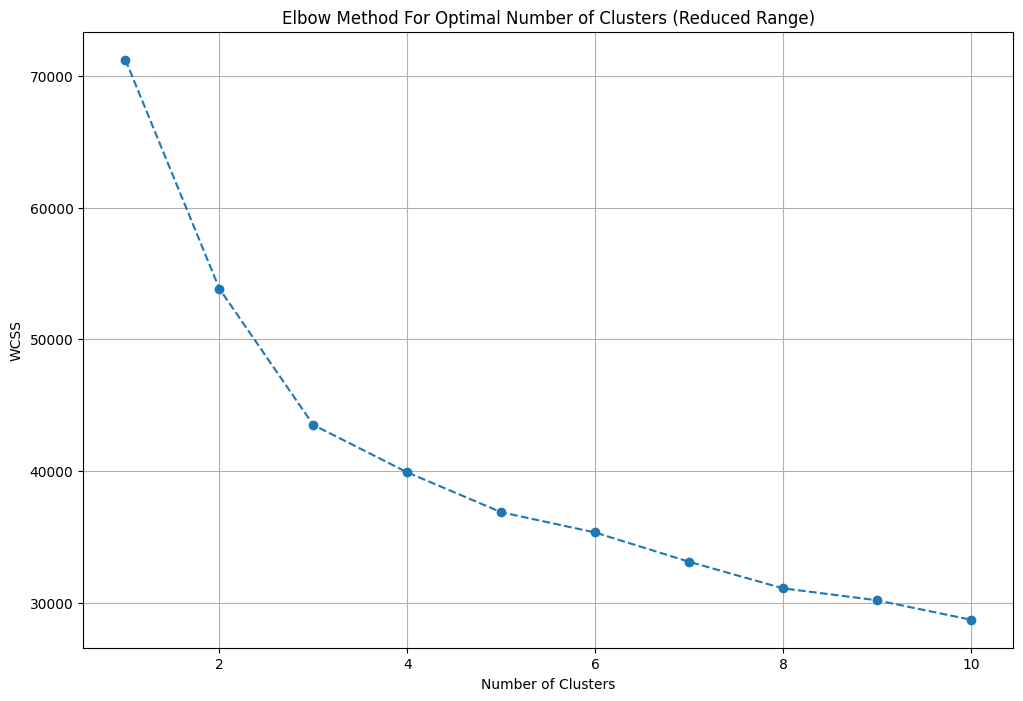

In [454]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [455]:
n_clusters = 3

# Fit the KMeans model
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(scaled_data)

# Predict the cluster assignments for each row
cluster_assignments = kmeans.predict(scaled_data)

In [456]:
df = df.iloc[:,:-18]

In [457]:
df['furnishing_type'] = cluster_assignments

In [458]:
df.sample(5)[['furnishDetails','furnishing_type']]
# 0 -> unfurnished
# 1 -> semifurnished
# 2 -> furnished

,furnishDetails,furnishing_type
3378,"['3 Wardrobe', '5 Fan', '1 Exhaust Fan', '1 Ge...",1
1621,"['2 Wardrobe', '1 Exhaust Fan', '2 Geyser', '1...",0
3511,"['1 Water Purifier', '10 Fan', '1 Fridge', '1 ...",2
3715,[],0
2586,NaN,0


## 5.features

In [459]:
df[['society','features']].sample(5)

,society,features
2690,bptp terra,"['Security / Fire Alarm', 'Feng Shui / Vaastu ..."
2191,ireo skyon,"['Centrally Air Conditioned', 'Water purifier'..."
3898,independent,NaN
3246,ats triumph,"['Centrally Air Conditioned', 'Water purifier'..."
1275,ansal maple heights,"['Centrally Air Conditioned', 'Water purifier'..."


In [460]:
df['features'].isnull().sum()

np.int64(706)

In [461]:
import pandas as pd
app_df = pd.read_csv('appartments.csv')
app_df.head(2)

,PropertyName,PropertySubName,NearbyLocations,LocationAdvantages,Link,PriceDetails,TopFacilities
0,Smartworld One DXP,"2, 3, 4 BHK Apartment in Sector 113, Gurgaon","['Bajghera Road', 'Palam Vihar Halt', 'DPSG Pa...","{'Bajghera Road': '800 Meter', 'Palam Vihar Ha...",https://www.99acres.com/smartworld-one-dxp-sec...,"{'2 BHK': {'building_type': 'Apartment', 'area...","['Swimming Pool', 'Salon', 'Restaurant', 'Spa'..."
1,M3M Crown,"3, 4 BHK Apartment in Sector 111, Gurgaon","['DPSG Palam Vihar Gurugram', 'The NorthCap Un...","{'DPSG Palam Vihar Gurugram': '1.4 Km', 'The N...",https://www.99acres.com/m3m-crown-sector-111-g...,"{'3 BHK': {'building_type': 'Apartment', 'area...","['Bowling Alley', 'Mini Theatre', 'Manicured G..."


In [462]:
app_df['PropertyName'] = app_df['PropertyName'].str.lower()

In [463]:
temp_df = df[df['features'].isnull()]

In [464]:
temp_df.shape

(706, 27)

In [465]:
x = temp_df.merge(app_df,left_on='society',right_on='PropertyName',how='left')['TopFacilities']

In [466]:
df.loc[temp_df.index,'features'] = x.values

In [467]:
df['features'].isnull().sum()

np.int64(549)

In [468]:

from sklearn.preprocessing import MultiLabelBinarizer
import ast

In [469]:
# Convert the string representation of lists in the 'features' column to actual lists
df['features_list'] = df['features'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) and x.startswith('[') else [])

# Use MultiLabelBinarizer to convert the features list into a binary matrix
mlb = MultiLabelBinarizer()
features_binary_matrix = mlb.fit_transform(df['features_list'])

# Convert the binary matrix into a DataFrame
features_binary_df = pd.DataFrame(features_binary_matrix, columns=mlb.classes_)

In [470]:
features_binary_df.sample(5)

,24/7 Power Backup,24/7 Water Supply,24x7 Security,ATM,Aerobics Centre,Air Hockey,Airy Rooms,Amphitheatre,Automated Car Wash,Badminton Court,...,Visitors Parking,Volley Ball Court,Waiting Lounge,Waste Disposal,Water Softener Plant,Water Storage,Water purifier,Water softening plant,Wi-Fi Connectivity,Yoga/Meditation Area
570,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,1,0,0
636,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3030,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,0
3235,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2224,0,0,0,0,0,0,1,0,0,0,...,0,0,0,1,0,0,1,1,0,0


In [471]:
features_binary_df.shape

(3957, 130)

In [472]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(features_binary_df)
    wcss_reduced.append(kmeans.inertia_)

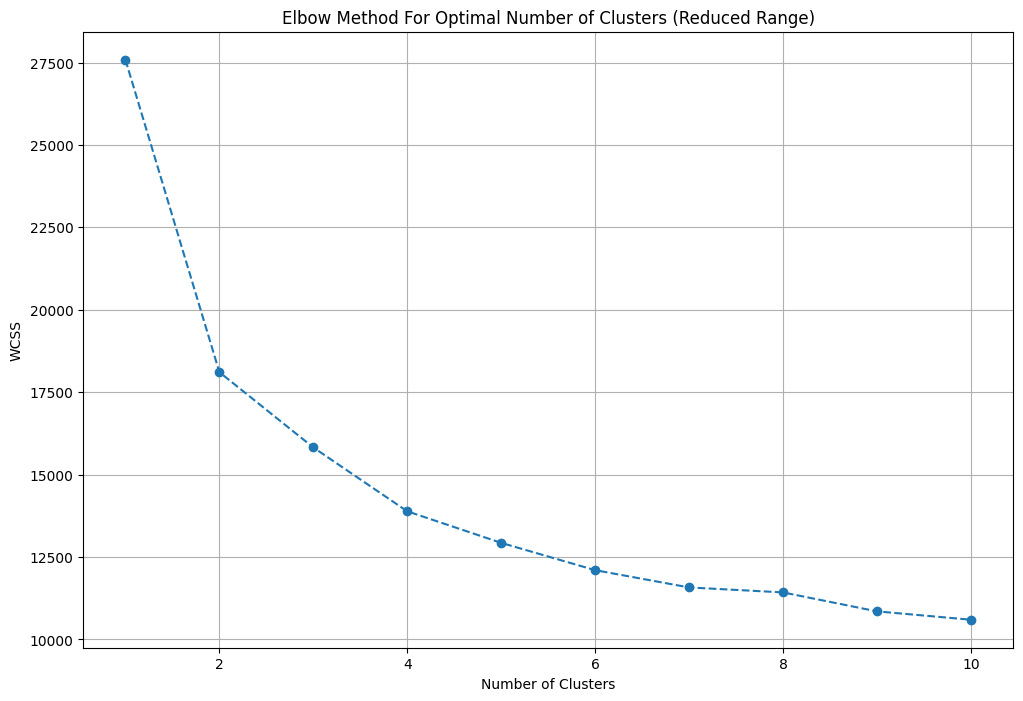

In [473]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [474]:
# Define the weights for each feature as provided
# Assigning weights based on perceived luxury contribution
weights = {
    '24/7 Power Backup': 8,
    '24/7 Water Supply': 4,
    '24x7 Security': 7,
    'ATM': 4,
    'Aerobics Centre': 6,
    'Airy Rooms': 8,
    'Amphitheatre': 7,
    'Badminton Court': 7,
    'Banquet Hall': 8,
    'Bar/Chill-Out Lounge': 9,
    'Barbecue': 7,
    'Basketball Court': 7,
    'Billiards': 7,
    'Bowling Alley': 8,
    'Business Lounge': 9,
    'CCTV Camera Security': 8,
    'Cafeteria': 6,
    'Car Parking': 6,
    'Card Room': 6,
    'Centrally Air Conditioned': 9,
    'Changing Area': 6,
    "Children's Play Area": 7,
    'Cigar Lounge': 9,
    'Clinic': 5,
    'Club House': 9,
    'Concierge Service': 9,
    'Conference room': 8,
    'Creche/Day care': 7,
    'Cricket Pitch': 7,
    'Doctor on Call': 6,
    'Earthquake Resistant': 5,
    'Entrance Lobby': 7,
    'False Ceiling Lighting': 6,
    'Feng Shui / Vaastu Compliant': 5,
    'Fire Fighting Systems': 8,
    'Fitness Centre / GYM': 8,
    'Flower Garden': 7,
    'Food Court': 6,
    'Foosball': 5,
    'Football': 7,
    'Fountain': 7,
    'Gated Community': 7,
    'Golf Course': 10,
    'Grocery Shop': 6,
    'Gymnasium': 8,
    'High Ceiling Height': 8,
    'High Speed Elevators': 8,
    'Infinity Pool': 9,
    'Intercom Facility': 7,
    'Internal Street Lights': 6,
    'Internet/wi-fi connectivity': 7,
    'Jacuzzi': 9,
    'Jogging Track': 7,
    'Landscape Garden': 8,
    'Laundry': 6,
    'Lawn Tennis Court': 8,
    'Library': 8,
    'Lounge': 8,
    'Low Density Society': 7,
    'Maintenance Staff': 6,
    'Manicured Garden': 7,
    'Medical Centre': 5,
    'Milk Booth': 4,
    'Mini Theatre': 9,
    'Multipurpose Court': 7,
    'Multipurpose Hall': 7,
    'Natural Light': 8,
    'Natural Pond': 7,
    'Park': 8,
    'Party Lawn': 8,
    'Piped Gas': 7,
    'Pool Table': 7,
    'Power Back up Lift': 8,
    'Private Garden / Terrace': 9,
    'Property Staff': 7,
    'RO System': 7,
    'Rain Water Harvesting': 7,
    'Reading Lounge': 8,
    'Restaurant': 8,
    'Salon': 8,
    'Sauna': 9,
    'Security / Fire Alarm': 9,
    'Security Personnel': 9,
    'Separate entry for servant room': 8,
    'Sewage Treatment Plant': 6,
    'Shopping Centre': 7,
    'Skating Rink': 7,
    'Solar Lighting': 6,
    'Solar Water Heating': 7,
    'Spa': 9,
    'Spacious Interiors': 9,
    'Squash Court': 8,
    'Steam Room': 9,
    'Sun Deck': 8,
    'Swimming Pool': 8,
    'Temple': 5,
    'Theatre': 9,
    'Toddler Pool': 7,
    'Valet Parking': 9,
    'Video Door Security': 9,
    'Visitor Parking': 7,
    'Water Softener Plant': 7,
    'Water Storage': 7,
    'Water purifier': 7,
    'Yoga/Meditation Area': 7
}
# Calculate luxury score for each row
luxury_score = features_binary_df[list(weights.keys())].multiply(list(weights.values())).sum(axis=1)


In [475]:
df['luxury_score'] = luxury_score

In [476]:
df.head()

,property_type,society,sector,price,price_per_sqft,Estimated_area,areaWithType,bedRoom,bathroom,balcony,...,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,features_list,luxury_score
0,flat,ss,sector 85,1.18,7170.0,1646.0,Super Built up area 1640(152.36 sq.m.)Built Up...,2,2,3,...,1630.0,1620.0,0,0,0,0,0,0,"[Feng Shui / Vaastu Compliant, Security / Fire...",49
1,house,independent,sector 57,8.31,24171.0,3438.0,Plot area 382(319.4 sq.m.),5,6,3+,...,3438.0,NaN,1,1,1,1,0,0,"[Feng Shui / Vaastu Compliant, False Ceiling L...",34
2,house,independent,sector 6,1.25,11574.0,1080.0,Plot area 120(100.34 sq.m.)Built Up area: 120 ...,5,5,1,...,1080.0,NaN,0,0,0,1,0,0,[],0
3,flat,supertech araville,sector 79,0.95,6209.0,1530.0,Super Built up area 1530(142.14 sq.m.),2,2,3,...,NaN,NaN,1,0,0,0,0,0,"[Feng Shui / Vaastu Compliant, Security / Fire...",49
4,flat,ambience creacions,sector 22,3.20,11500.0,2783.0,Super Built up area 2781(258.36 sq.m.),3,4,3+,...,NaN,NaN,0,0,0,0,0,0,"[Feng Shui / Vaastu Compliant, Security / Fire...",42


In [477]:
# cols to drop -> nearbyLocations,furnishDetails, features,features_list, additionalRoom
df.drop(columns=['nearbyLocations','furnishDetails','features','features_list','additionalRoom'],inplace=True)

In [478]:

df.sample(5)


,property_type,society,sector,price,price_per_sqft,Estimated_area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2876,flat,tulip violet,sector 69,1.700,8457.0,2010.0,Super Built up area 2010(186.74 sq.m.)Carpet a...,4,4,2,...,2010.0,NaN,1610.0,1,1,1,1,0,0,174
3490,house,independent,sector 25,10.000,37037.0,2700.0,Plot area 2700(250.84 sq.m.)Built Up area: 950...,5,5,3+,...,NaN,9500.0,9000.0,0,1,0,1,0,2,29
2352,flat,prime habitat,sector 99a,0.271,6049.0,448.0,Carpet area: 448 (41.62 sq.m.),2,2,1,...,NaN,NaN,448.0,0,0,0,0,0,0,67
49,flat,ramprastha the edge towers,sector 37d,0.800,5797.0,1380.0,Super Built up area 1380(128.21 sq.m.)Built Up...,2,2,3,...,1380.0,1300.0,1200.0,0,0,0,0,0,0,78
1189,house,private house,sector 55,7.050,46906.0,1503.0,Plot area 167(139.63 sq.m.),18,18,3+,...,NaN,1503.0,NaN,0,0,0,0,1,2,57


In [479]:
df.shape

(3957, 24)

In [480]:
df.to_csv('gurgaon_properties_cleaned_v2.csv',index=False)